# URGENT HYBRID — CNN + XGBoost no split patient-aware

Notebook único para correr **uma noite antes da apresentação**.

**Como usar:**
1. Edita a célula `CONFIG` em baixo: aponta para o teu dataset patient-aware e escolhe o modelo.
2. Corre todas as células de cima a baixo.
3. Repete (mudando só o CONFIG) para cada modelo que tenhas `.pth`. Cada corrida guarda previsões em `./preds/`.
4. No fim, corre a célula de ENSEMBLE para juntar todos.

**Ordem recomendada (rapidez):** DEIT3 → DENSENET → MOBILENET → RESNET → EFFICIENTNET (B7 é lento).


In [1]:
import os, time, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from monai.transforms import (LoadImage, EnsureChannelFirst, Resize,
                               NormalizeIntensity, Lambda, ToTensor, Compose)

from sklearn.metrics import (f1_score, accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_sample_weight

import xgboost as xgb

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device = {device}")
os.makedirs("./preds", exist_ok=True)

device = cuda


## ⚙️ CONFIG — edita ANTES de correr

In [2]:
# === EDITAR AQUI ===

# Caminho para o dataset patient-aware (output do split_dataset.ipynb)
# Tem de ter subpastas: train/<classe>/*.png, val/<classe>/*.png, test/<classe>/*.png
DATASET_DIR = '../dataset'

# Escolhe um modelo de cada vez. Tipos suportados:
#   'deit3'      -> deit3_small_patch16_384 (input 384)
#   'densenet'   -> DenseNet121 do MONAI (input 512)
#   'resnet'     -> resnet50 do torchvision (input 512)
#   'efficientnet'-> efficientnet_b7 do torchvision (input 512)
#   'mobilenet'  -> mobilenet_v2 do torchvision (input 512)
MODEL_TYPE = 'resnet'

# Caminho para o .pth correspondente (vindo do repo base ou treino teu)
MODEL_PTH = './models/resnet50.pth'

# Identificador único para guardar previsões (não usar espaços)
RUN_TAG = MODEL_TYPE   # ou 'deit3_v1', 'densenet_clahe', etc.

# Configurações comuns
BATCH_SIZE = 16     # baixa para 8 se OOM (sobretudo no EfficientNet-B7)
NUM_WORKERS = 0
NUM_CLASS = 4
print(f"Vais correr: {MODEL_TYPE.upper()}  |  .pth = {MODEL_PTH}  |  tag = {RUN_TAG}")

Vais correr: RESNET  |  .pth = ./models/resnet50.pth  |  tag = resnet


## 1. Carregar listas de imagens (split patient-aware já feito)

In [3]:
phases = ['train', 'val', 'test']
class_names = sorted([x for x in os.listdir(os.path.join(DATASET_DIR, 'train'))
                      if os.path.isdir(os.path.join(DATASET_DIR, 'train', x))])
assert len(class_names) == NUM_CLASS, f"Esperava {NUM_CLASS} classes, encontrei {len(class_names)}: {class_names}"

data = {p: {'images': [], 'labels': []} for p in phases}
for p in phases:
    for i, cls in enumerate(class_names):
        d = os.path.join(DATASET_DIR, p, cls)
        for f in sorted(os.listdir(d)):
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
                data[p]['images'].append(os.path.join(d, f))
                data[p]['labels'].append(i)

for p in phases:
    counts = np.bincount(data[p]['labels'], minlength=NUM_CLASS)
    print(f"{p}: {len(data[p]['images']):>4d} imgs  ->  {dict(zip(class_names, counts.tolist()))}")
print(f"classes (ordem): {class_names}")

train: 1067 imgs  ->  {'Biliary_Leaks': 110, 'Lithiasis': 505, 'Normal': 197, 'Stricture': 255}
val:  234 imgs  ->  {'Biliary_Leaks': 24, 'Lithiasis': 98, 'Normal': 59, 'Stricture': 53}
test:  267 imgs  ->  {'Biliary_Leaks': 17, 'Lithiasis': 123, 'Normal': 43, 'Stricture': 84}
classes (ordem): ['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']


## 2. Transforms — IGUAIS às do treino original
Não acrescentamos CLAHE aqui (o .pth não foi treinado com CLAHE; aplicar agora só piora).


In [4]:
# Resolução depende do modelo (DeiT3 usa 384, todos os outros 512)
IMG_SIZE = 384 if MODEL_TYPE == 'deit3' else 512

def repeat_if_needed(img):
    return img.repeat(3, 1, 1) if img.shape[0] == 1 else img

# Para extração de features NÃO queremos augmentation (mesma transform em todos os splits)
inference_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((IMG_SIZE, IMG_SIZE)),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

class ERCPDataset(Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files, self.labels, self.transforms = image_files, labels, transforms
    def __len__(self): return len(self.image_files)
    def __getitem__(self, i):
        return self.transforms(self.image_files[i]), self.labels[i]

train_loader = DataLoader(ERCPDataset(data['train']['images'], data['train']['labels'], inference_transforms),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(ERCPDataset(data['val']['images'],   data['val']['labels'],   inference_transforms),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(ERCPDataset(data['test']['images'],  data['test']['labels'],  inference_transforms),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
print(f"loaders prontos: img_size={IMG_SIZE}")

loaders prontos: img_size=512


## 3. Carregar modelo (.pth) e cortar a cabeça

In [5]:
def load_model_and_strip_head(model_type, pth_path, num_class):
    if model_type == 'deit3':
        import timm
        m = timm.create_model('deit3_small_patch16_384', pretrained=False, in_chans=3)
        m.head = nn.Linear(m.head.in_features, num_class)
        state = torch.load(pth_path, map_location=device)
        m.load_state_dict(state)
        feat_dim = m.head.in_features
        m.head = nn.Identity()
    elif model_type == 'densenet':
        from monai.networks.nets import DenseNet121
        m = DenseNet121(spatial_dims=2, in_channels=3, out_channels=num_class, pretrained=False)
        state = torch.load(pth_path, map_location=device)
        m.load_state_dict(state)
        feat_dim = 1024
        m.class_layers.out = nn.Identity()
    elif model_type == 'resnet':
        from torchvision.models import resnet50
        m = resnet50(weights=None)
        m.fc = nn.Linear(m.fc.in_features, num_class)
        state = torch.load(pth_path, map_location=device)
        m.load_state_dict(state)
        feat_dim = m.fc.in_features
        m.fc = nn.Identity()
    elif model_type == 'efficientnet':
        from torchvision.models import efficientnet_b7
        m = efficientnet_b7(weights=None)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_class)
        state = torch.load(pth_path, map_location=device)
        m.load_state_dict(state)
        feat_dim = m.classifier[1].in_features
        m.classifier = nn.Identity()
    elif model_type == 'mobilenet':
        from torchvision.models import mobilenet_v2
        m = mobilenet_v2(weights=None)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_class)
        state = torch.load(pth_path, map_location=device)
        m.load_state_dict(state)
        feat_dim = m.classifier[1].in_features
        m.classifier = nn.Identity()
    else:
        raise ValueError(f"model_type desconhecido: {model_type}")
    m = m.to(device).eval()
    return m, feat_dim

model, feat_dim = load_model_and_strip_head(MODEL_TYPE, MODEL_PTH, NUM_CLASS)
print(f"Modelo {MODEL_TYPE} carregado. feature_dim={feat_dim}")

C:\Users\bruno\AppData\Local\Temp\ipykernel_32176\480003976.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(pth_path, map_location=device)


Modelo resnet carregado. feature_dim=2048


## 4. Extrair features + avaliar CNN puro como baseline

In [6]:
@torch.no_grad()
def extract_features(loader, model):
    feats, lbls = [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        f = model(x).cpu().numpy()
        if f.ndim > 2:
            f = f.reshape(f.shape[0], -1)
        feats.append(f); lbls.append(y.numpy())
    return np.concatenate(feats), np.concatenate(lbls)

print("A extrair features... (1-3 min por split tipicamente)")
t0 = time.perf_counter()
X_train, y_train = extract_features(train_loader, model); print(f"  train: {X_train.shape} ({time.perf_counter()-t0:.1f}s)")
t0 = time.perf_counter()
X_val,   y_val   = extract_features(val_loader,   model); print(f"  val:   {X_val.shape}   ({time.perf_counter()-t0:.1f}s)")
t0 = time.perf_counter()
X_test,  y_test  = extract_features(test_loader,  model); print(f"  test:  {X_test.shape}  ({time.perf_counter()-t0:.1f}s)")

A extrair features... (1-3 min por split tipicamente)


KeyboardInterrupt: 

In [ ]:
# ---- BASELINE: CNN puro (recriar a cabeça e usar para previsão) ----
# Estamos a recarregar o modelo COM cabeça para ver o que o CNN sozinho dá no teste.
print("\n=== BASELINE CNN puro (sem XGBoost) ===")
baseline_model, _ = load_model_and_strip_head(MODEL_TYPE, MODEL_PTH, NUM_CLASS)
# Recarrega só para confirmar — load_model_and_strip_head já deu eval() e cortou a cabeça.
# Para o baseline precisamos da cabeça original. Tornamos a carregá-la:

# Pequeno truque: recarregar o modelo COM cabeça intacta
if MODEL_TYPE == 'deit3':
    import timm
    full = timm.create_model('deit3_small_patch16_384', pretrained=False, in_chans=3)
    full.head = nn.Linear(full.head.in_features, NUM_CLASS)
elif MODEL_TYPE == 'densenet':
    from monai.networks.nets import DenseNet121
    full = DenseNet121(spatial_dims=2, in_channels=3, out_channels=NUM_CLASS, pretrained=False)
elif MODEL_TYPE == 'resnet':
    from torchvision.models import resnet50
    full = resnet50(weights=None); full.fc = nn.Linear(full.fc.in_features, NUM_CLASS)
elif MODEL_TYPE == 'efficientnet':
    from torchvision.models import efficientnet_b7
    full = efficientnet_b7(weights=None); full.classifier[1] = nn.Linear(full.classifier[1].in_features, NUM_CLASS)
elif MODEL_TYPE == 'mobilenet':
    from torchvision.models import mobilenet_v2
    full = mobilenet_v2(weights=None); full.classifier[1] = nn.Linear(full.classifier[1].in_features, NUM_CLASS)
full.load_state_dict(torch.load(MODEL_PTH, map_location=device))
full = full.to(device).eval()

@torch.no_grad()
def cnn_predict(loader, m, use_tta=True):
    probas, lbls = [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        p = F.softmax(m(x), dim=1)
        if use_tta:
            p = p + F.softmax(m(torch.flip(x, dims=[3])), dim=1)
            p = p + F.softmax(m(torch.rot90(x,  1, dims=[2,3])), dim=1)
            p = p + F.softmax(m(torch.rot90(x, -1, dims=[2,3])), dim=1)
            p = p / 4.0
        probas.append(p.cpu().numpy()); lbls.append(y.numpy())
    return np.concatenate(probas), np.concatenate(lbls)

cnn_proba_test, _ = cnn_predict(test_loader, full)
cnn_preds_test = cnn_proba_test.argmax(1)
cnn_f1 = f1_score(y_test, cnn_preds_test, average='macro')
print(f">>> CNN puro F1 macro (test) = {cnn_f1:.4f}")
print(classification_report(y_test, cnn_preds_test, target_names=class_names, digits=4, zero_division=0))

del full   # liberta memória
torch.cuda.empty_cache()


=== BASELINE CNN puro (sem XGBoost) ===


C:\Users\bruno\AppData\Local\Temp\ipykernel_24072\480003976.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(pth_path, map_location=device)
C:\Users\b

>>> CNN puro F1 macro (test) = 0.5688
               precision    recall  f1-score   support

Biliary_Leaks     0.3846    0.2941    0.3333        17
    Lithiasis     0.6474    0.9106    0.7568       123
       Normal     0.7500    0.2791    0.4068        43
    Stricture     0.8923    0.6905    0.7785        84

     accuracy                         0.7004       267
    macro avg     0.6686    0.5436    0.5688       267
 weighted avg     0.7242    0.7004    0.6803       267



## 5. Treinar XGBoost por cima das features

In [ ]:
# Pesos por amostra para lidar com desbalanceamento
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
print(f"Sample weights distribution: min={sample_weights.min():.3f}, max={sample_weights.max():.3f}")

# Tentar GPU primeiro, com fallback automático para CPU
xgb_device = 'cuda' if torch.cuda.is_available() else 'cpu'

xgb_base = xgb.XGBClassifier(
    objective='multi:softprob', num_class=NUM_CLASS,
    eval_metric='mlogloss', tree_method='hist',
    device=xgb_device,
    random_state=42, verbosity=0,
)

# Grid pequena mas eficaz (~5-10 min)
param_grid = {
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.03, 0.1],
    'n_estimators':  [200, 500],
}

print("Grid search (3-fold CV no train, scoring=f1_macro)...")
t0 = time.perf_counter()
grid = GridSearchCV(xgb_base, param_grid, scoring='f1_macro', cv=3, n_jobs=1, verbose=1)
try:
    grid.fit(X_train, y_train, sample_weight=sample_weights)
except Exception as e:
    print(f"⚠️ GPU XGBoost falhou ({e}). A tentar em CPU...")
    xgb_base = xgb.XGBClassifier(
        objective='multi:softprob', num_class=NUM_CLASS,
        eval_metric='mlogloss', tree_method='hist',
        device='cpu', random_state=42, verbosity=0,
    )
    grid = GridSearchCV(xgb_base, param_grid, scoring='f1_macro', cv=3, n_jobs=-1, verbose=1)
    grid.fit(X_train, y_train, sample_weight=sample_weights)

print(f"\nGrid search demorou {(time.perf_counter()-t0)/60:.2f} min")
print(f"Melhores params (CV no train): {grid.best_params_}")
print(f"Melhor F1 macro CV (train): {grid.best_score_:.4f}")
best_xgb = grid.best_estimator_

import joblib
os.makedirs('./models', exist_ok=True)
joblib.dump(best_xgb, f'./models/{RUN_TAG}_xgb.pkl')
print(f"✅ XGBoost guardado: ./models/{RUN_TAG}_xgb.pkl")

Sample weights distribution: min=0.528, max=2.425
Grid search (3-fold CV no train, scoring=f1_macro)...
Fitting 3 folds for each of 12 candidates, totalling 36 fits


KeyboardInterrupt: 

## 6. Avaliar no TEST set

In [ ]:
# Previsões finais no teste
xgb_proba_test = best_xgb.predict_proba(X_test)
xgb_preds_test = xgb_proba_test.argmax(1)

f1_test = f1_score(y_test, xgb_preds_test, average='macro')
acc_test = accuracy_score(y_test, xgb_preds_test)
y_bin = label_binarize(y_test, classes=np.arange(NUM_CLASS))
try:
    auc_test = roc_auc_score(y_bin, xgb_proba_test, average='macro', multi_class='ovr')
except Exception:
    auc_test = float('nan')

print(f"\n{'='*60}")
print(f"🏆 {MODEL_TYPE.upper()} + XGBoost (TEST)")
print(f"{'='*60}")
print(f"  F1 macro  : {f1_test:.4f}    (CNN puro: {cnn_f1:.4f}  | baseline paper: 0.738)")
print(f"  Accuracy  : {acc_test:.4f}")
print(f"  AUC macro : {auc_test:.4f}")
print()
print(classification_report(y_test, xgb_preds_test, target_names=class_names, digits=4, zero_division=0))

# Matriz de confusão
cm  = confusion_matrix(y_test, xgb_preds_test)
cmn = confusion_matrix(y_test, xgb_preds_test, normalize='true')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title(f'{MODEL_TYPE} — matriz de confusão (abs)'); axes[0].set_xlabel('Previsto'); axes[0].set_ylabel('Real')
sns.heatmap(cmn, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title(f'{MODEL_TYPE} — normalizada'); axes[1].set_xlabel('Previsto'); axes[1].set_ylabel('Real')
plt.tight_layout()
plt.savefig(f'./preds/{RUN_TAG}_cm.png', dpi=200, bbox_inches='tight')
plt.show()

NameError: name 'best_xgb' is not defined

In [ ]:
# Guardar previsões para o ensemble no fim
np.savez(f'./preds/{RUN_TAG}_predictions.npz',
         xgb_proba=xgb_proba_test,
         cnn_proba=cnn_proba_test,
         actuals=y_test,
         class_names=np.array(class_names),
         cnn_f1=cnn_f1,
         xgb_f1=f1_test,
         best_params=str(grid.best_params_))
print(f"✅ Guardado em ./preds/{RUN_TAG}_predictions.npz")
print(f"\n  -> agora podes mudar o CONFIG para outro modelo e voltar a correr de cima.")

✅ Guardado em ./preds/resnet_predictions.npz

  -> agora podes mudar o CONFIG para outro modelo e voltar a correr de cima.


## 7. ENSEMBLE de todos os modelos que correste

Só correr esta secção depois de teres pelo menos 2 modelos guardados em `./preds/`.

In [8]:
# Ensemble misto: usa a melhor variante de cada modelo
custom_picks = {
    'densenet': 'cnn',       # 0.6207 > 0.5353
    'resnet': 'xgb',         # 0.7035 > 0.5682  <
    'efficientnet': 'cnn',   # 0.7381 > 0.6949
    'mobilenet': 'cnn',      # 0.5894 > 0.5842
}

probas_list = []
actuals_ref = None
for tag, kind in custom_picks.items():
    d = np.load(f'./preds/{tag}_predictions.npz', allow_pickle=True)
    probas_list.append(d[f'{kind}_proba'])
    if actuals_ref is None:
        actuals_ref = d['actuals']

ens_proba = np.mean(np.stack(probas_list, axis=0), axis=0)
ens_preds = ens_proba.argmax(1)
print(f"MIXED ENSEMBLE F1 macro = {f1_score(actuals_ref, ens_preds, average='macro'):.4f}")
print(classification_report(actuals_ref, ens_preds, target_names=class_names, digits=4))

# Pesos proporcionais ao F1 individual
weights = {'densenet': 0.6207, 'resnet': 0.7035, 'efficientnet': 0.7381, 'mobilenet': 0.5894}
W = np.array([weights[k] for k in custom_picks.keys()])
W = W / W.sum()
ens_proba_w = np.sum(np.stack(probas_list, axis=0) * W.reshape(-1, 1, 1), axis=0)
ens_preds_w = ens_proba_w.argmax(1)
print(f"WEIGHTED ENSEMBLE F1 macro = {f1_score(actuals_ref, ens_preds_w, average='macro'):.4f}")

MIXED ENSEMBLE F1 macro = 0.7797
               precision    recall  f1-score   support

Biliary_Leaks     0.8462    0.6471    0.7333        17
    Lithiasis     0.7820    0.8455    0.8125       123
       Normal     0.6610    0.9070    0.7647        43
    Stricture     0.9516    0.7024    0.8082        84

     accuracy                         0.7978       267
    macro avg     0.8102    0.7755    0.7797       267
 weighted avg     0.8199    0.7978    0.7984       267

WEIGHTED ENSEMBLE F1 macro = 0.7797


## 9. Análise clínica — Falsos Negativos de Stricture

Stricture é a classe clinicamente mais perigosa (pode mascarar tumores). Aplicamos um **threshold ajustado** para aumentar o recall, aceitando mais falsos positivos. Também fazemos um sanity check em Biliary_Leaks (só 17 imagens no test).


Threshold    Recall Stricture     F1 macro     Acc     
-------------------------------------------------------
0.10         0.9405               0.7271       0.7303
0.15         0.9167               0.7681       0.7828
0.20         0.9048               0.7898       0.8127
0.25         0.8452               0.7811       0.8052
0.30         0.8333               0.7855       0.8090
0.35         0.8214               0.7993       0.8240
0.40         0.7500               0.7857       0.8052

Threshold = 0.2
Recall Stricture : 0.7024  ->  0.9048  (Delta=+0.2024)
F1 macro         : 0.7797  ->  0.7898  (Delta=+0.0101)

               precision    recall  f1-score   support

Biliary_Leaks     0.9167    0.6471    0.7586        17
    Lithiasis     0.8796    0.7724    0.8225       123
       Normal     0.6364    0.8140    0.7143        43
    Stricture     0.8261    0.9048    0.8636        84

     accuracy                         0.8127       267
    macro avg     0.8147    0.7845    0.7898     

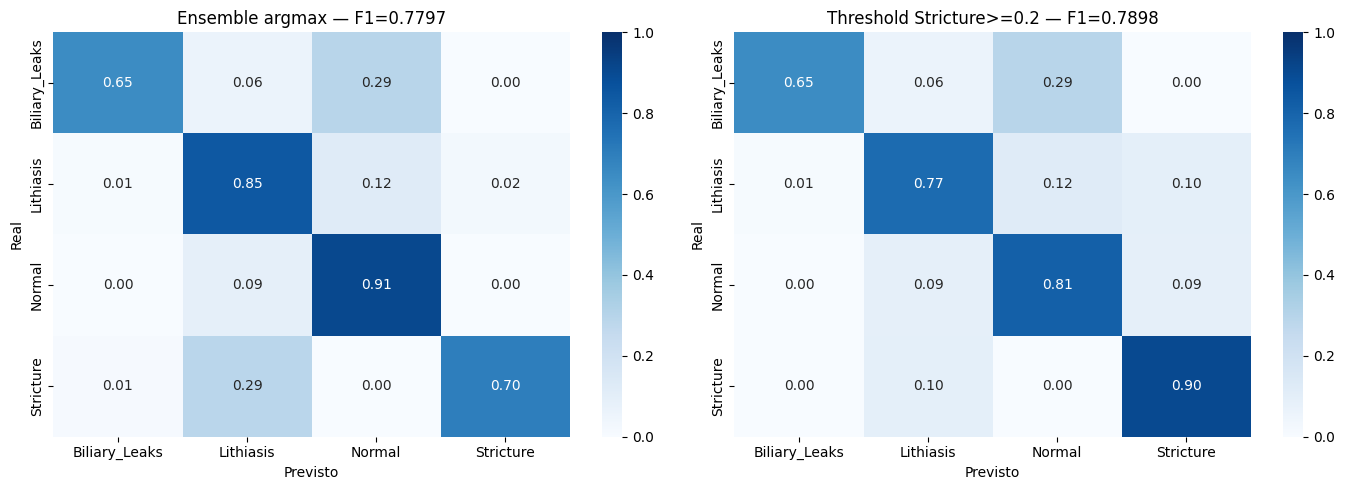

Figura guardada: ./preds/stricture_threshold_comparison.png


In [9]:
### Opção A — Cost-sensitive threshold para Stricture
import numpy as np
from sklearn.metrics import recall_score, f1_score, accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ens_proba e actuals_ref definidos na célula do ensemble (Secção 7)
STRICTURE_IDX = list(class_names).index('Stricture')

preds_baseline = ens_proba.argmax(1)
recall_baseline = recall_score(actuals_ref, preds_baseline, labels=[STRICTURE_IDX], average='macro')
f1_baseline     = f1_score(actuals_ref, preds_baseline, average='macro')

# Varredura de thresholds
print(f"\n{'Threshold':<12} {'Recall Stricture':<20} {'F1 macro':<12} {'Acc':<8}")
print("-" * 55)
results_thresh = []
for thresh in np.arange(0.10, 0.45, 0.05):
    preds_adj = preds_baseline.copy()
    preds_adj[ens_proba[:, STRICTURE_IDX] > thresh] = STRICTURE_IDX
    rec = recall_score(actuals_ref, preds_adj, labels=[STRICTURE_IDX], average='macro')
    f1  = f1_score(actuals_ref, preds_adj, average='macro')
    acc = accuracy_score(actuals_ref, preds_adj)
    print(f"{thresh:<12.2f} {rec:<20.4f} {f1:<12.4f} {acc:.4f}")
    results_thresh.append((thresh, rec, f1, acc))

# Aplicar threshold recomendado
STRICTURE_THRESHOLD = 0.20
preds_adjusted = preds_baseline.copy()
preds_adjusted[ens_proba[:, STRICTURE_IDX] > STRICTURE_THRESHOLD] = STRICTURE_IDX

recall_after = recall_score(actuals_ref, preds_adjusted, labels=[STRICTURE_IDX], average='macro')
f1_after     = f1_score(actuals_ref, preds_adjusted, average='macro')

print(f"\n{'='*55}")
print(f"Threshold = {STRICTURE_THRESHOLD}")
print(f"Recall Stricture : {recall_baseline:.4f}  ->  {recall_after:.4f}  (Delta={recall_after-recall_baseline:+.4f})")
print(f"F1 macro         : {f1_baseline:.4f}  ->  {f1_after:.4f}  (Delta={f1_after-f1_baseline:+.4f})")
print()
print(classification_report(actuals_ref, preds_adjusted, target_names=class_names, digits=4, zero_division=0))

# Matrizes comparativas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, preds, title in zip(axes,
    [preds_baseline, preds_adjusted],
    [f'Ensemble argmax — F1={f1_baseline:.4f}',
     f'Threshold Stricture>={STRICTURE_THRESHOLD} — F1={f1_after:.4f}']):
    cm = confusion_matrix(actuals_ref, preds, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(title); ax.set_xlabel('Previsto'); ax.set_ylabel('Real')
plt.tight_layout()
plt.savefig('./preds/stricture_threshold_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figura guardada: ./preds/stricture_threshold_comparison.png")

In [10]:
### Sanity check — Biliary_Leaks (17 imagens no test)
BL_IDX = list(class_names).index('Biliary_Leaks')
bl_indices = np.where(actuals_ref == BL_IDX)[0]

print(f"\n{'Idx':<5} {'GT':<15} {'Pred':<15} {'BL':<8} {'Li':<8} {'No':<8} {'St':<8} {'Analise'}")
print("-" * 90)
for i in bl_indices:
    probs = ens_proba[i]
    pred_idx = int(probs.argmax())
    sorted_idx = probs.argsort()[::-1]
    top1, top2 = probs[sorted_idx[0]], probs[sorted_idx[1]]
    if pred_idx == BL_IDX:
        status = "OK acerto"
    elif (top1 - top2) < 0.15:
        status = f"50/50 com {class_names[sorted_idx[1]]}"
    else:
        status = f"ERRADO -> {class_names[pred_idx]}"
    print(f"{i:<5} Biliary_Leaks  {class_names[pred_idx]:<15} "
          f"{probs[0]:.3f}   {probs[1]:.3f}   {probs[2]:.3f}   {probs[3]:.3f}   {status}")

n_correct = int((ens_proba[bl_indices].argmax(1) == BL_IDX).sum())
n_5050 = sum(1 for i in bl_indices
             if int(ens_proba[i].argmax()) != BL_IDX
             and (ens_proba[i].max() - np.sort(ens_proba[i])[-2]) < 0.15)
n_conf = sum(1 for i in bl_indices
             if int(ens_proba[i].argmax()) != BL_IDX
             and (ens_proba[i].max() - np.sort(ens_proba[i])[-2]) >= 0.15)

print(f"\nTotal Biliary_Leaks no test : {len(bl_indices)}")
print(f"Acertos                     : {n_correct}")
print(f"Confidence media na classe verdadeira    : {ens_proba[bl_indices, BL_IDX].mean():.3f}")
print(f"Confidence media na classe prevista (max): {ens_proba[bl_indices].max(1).mean():.3f}")
print(f"\n--- Diagnostico ---")
print(f"  Corretos        : {n_correct}/{len(bl_indices)}")
print(f"  Erros 50/50     : {n_5050}  (modelo hesita)")
print(f"  Erros confiantes: {n_conf}  (modelo aprendeu mal esta classe)")
if ens_proba[bl_indices, BL_IDX].mean() < 0.20:
    print("  AVISO: Probabilidade media em BL < 0.20 -- subestimacao sistematica")


Idx   GT              Pred            BL       Li       No       St       Analise
------------------------------------------------------------------------------------------
0     Biliary_Leaks  Biliary_Leaks   0.661   0.133   0.157   0.048   OK acerto
1     Biliary_Leaks  Biliary_Leaks   0.648   0.129   0.182   0.041   OK acerto
2     Biliary_Leaks  Biliary_Leaks   0.609   0.095   0.273   0.024   OK acerto
3     Biliary_Leaks  Lithiasis       0.329   0.510   0.096   0.065   ERRADO -> Lithiasis
4     Biliary_Leaks  Biliary_Leaks   0.598   0.191   0.159   0.052   OK acerto
5     Biliary_Leaks  Biliary_Leaks   0.454   0.118   0.393   0.035   OK acerto
6     Biliary_Leaks  Biliary_Leaks   0.463   0.261   0.228   0.048   OK acerto
7     Biliary_Leaks  Biliary_Leaks   0.480   0.315   0.119   0.087   OK acerto
8     Biliary_Leaks  Biliary_Leaks   0.812   0.071   0.105   0.013   OK acerto
9     Biliary_Leaks  Biliary_Leaks   0.547   0.183   0.241   0.028   OK acerto
10    Biliary_Leaks  Norma

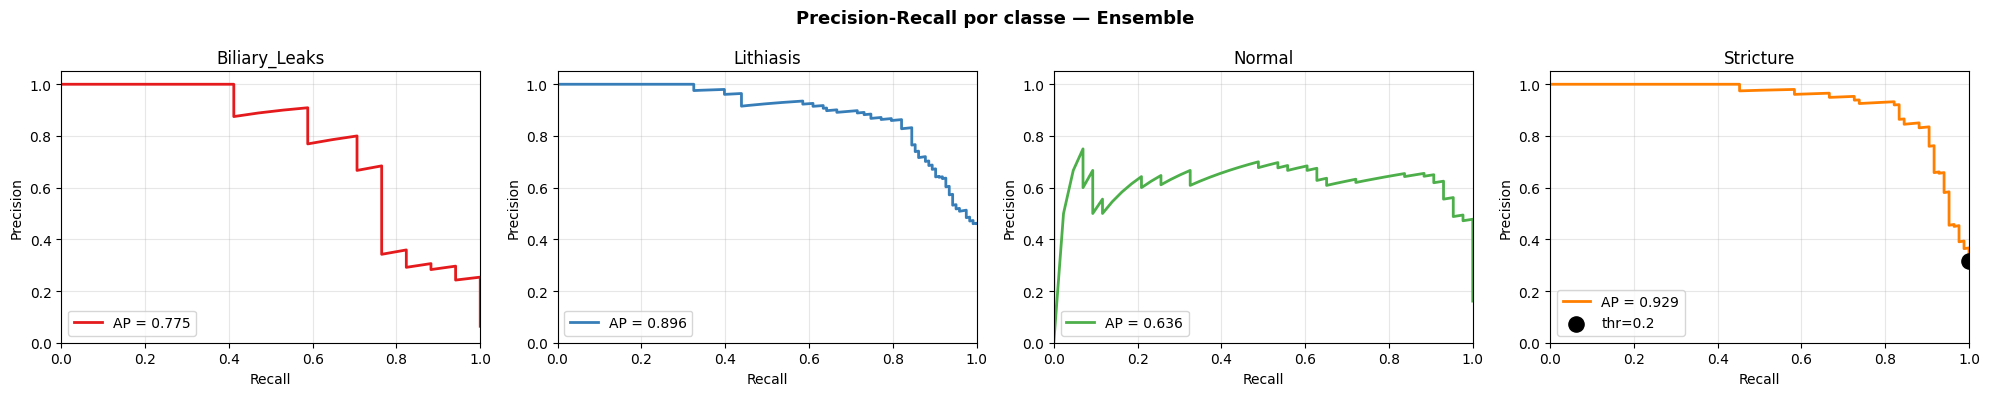

Figura guardada: ./preds/pr_curve_by_class.png


In [11]:
### Curva Precision-Recall por classe
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

y_bin_pr = label_binarize(actuals_ref, classes=np.arange(NUM_CLASS))
fig, axes = plt.subplots(1, NUM_CLASS, figsize=(5 * NUM_CLASS, 4))
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#ff7f00']

for i, (ax, cls, color) in enumerate(zip(axes, class_names, colors)):
    precision, recall, thresholds = precision_recall_curve(y_bin_pr[:, i], ens_proba[:, i])
    ap = average_precision_score(y_bin_pr[:, i], ens_proba[:, i])
    ax.plot(recall, precision, color=color, lw=2, label=f'AP = {ap:.3f}')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(cls); ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
    ax.legend(loc='lower left'); ax.grid(alpha=0.3)
    if cls == 'Stricture' and len(thresholds) > 0:
        t_idx = np.searchsorted(-thresholds, -STRICTURE_THRESHOLD)
        t_idx = max(0, min(t_idx, len(thresholds) - 1))
        ax.scatter(recall[t_idx], precision[t_idx], s=120, zorder=5, color='black',
                   label=f'thr={STRICTURE_THRESHOLD}')
        ax.legend(loc='lower left')

plt.suptitle('Precision-Recall por classe — Ensemble', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./preds/pr_curve_by_class.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figura guardada: ./preds/pr_curve_by_class.png")

## 10. Comparação CLAHE — preprocessamento justo

Aplicamos CLAHE na pipeline de **extração de features** (os backbones não são retreinados). Treinamos XGBoost em cima das features CLAHE para cada modelo e comparamos F1 macro apples-to-apples: XGB sem CLAHE vs XGB com CLAHE.

**Tempo estimado:** ~40 min (extração + XGBoost para 4 modelos).

In [12]:
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

class ERCPDatasetCLAHE(Dataset):
    """Dataset com CLAHE aplicado — deve ser usado com modelos treinados COM CLAHE."""
    def __init__(self, image_files, labels, img_size, apply_clahe=True):
        self.files = image_files
        self.labels = labels
        self.img_size = img_size
        self.clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8)) if apply_clahe else None

    def __len__(self): return len(self.files)

    def __getitem__(self, i):
        img = cv2.imread(self.files[i], cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (self.img_size, self.img_size))
        if self.clahe is not None:
            img = self.clahe.apply(img)
        img = img.astype(np.float32) / 255.0
        img = (img - img.mean()) / (img.std() + 1e-8)
        img = np.stack([img] * 3, axis=0)
        return torch.from_numpy(img), self.labels[i]

# Modelos treinados COM CLAHE (output dos notebooks base-repo/training/*_clahe.pth)
# Estes ficheiros existem depois de correres DENSENET.ipynb, RESNET.ipynb, etc. modificados
CLAHE_MODELS = {
    'densenet':    ('densenet',    '../base-repo/training/models/densenet_clahe.pth',      512),
    'resnet':      ('resnet',      '../base-repo/training/models/resnet50_clahe.pth',       512),
    'efficientnet':('efficientnet','../base-repo/training/models/efficientnet_b7_clahe.pth',512),
    'mobilenet':   ('mobilenet',   '../base-repo/training/models/mobilenet_v2_clahe.pth',   512),
}

print("Modelos CLAHE configurados:")
for tag, (mtype, pth, sz) in CLAHE_MODELS.items():
    exists = 'OK' if os.path.exists(pth) else 'AINDA NAO EXISTE (treinar primeiro)'
    print(f"  {tag:<15} {pth}  [{exists}]")

Modelos CLAHE configurados:
  densenet        ../base-repo/training/models/densenet_clahe.pth  [OK]
  resnet          ../base-repo/training/models/resnet50_clahe.pth  [OK]
  efficientnet    ../base-repo/training/models/efficientnet_b7_clahe.pth  [AINDA NAO EXISTE (treinar primeiro)]
  mobilenet       ../base-repo/training/models/mobilenet_v2_clahe.pth  [OK]


In [13]:
### Loop principal — extração CLAHE + XGBoost por modelo (~40 min total)
import joblib, time
import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import f1_score, accuracy_score, classification_report

_xgb_device = 'cuda' if torch.cuda.is_available() else 'cpu'
clahe_results = {}

for tag, (mtype, pth_path, img_size) in CLAHE_MODELS.items():
    if not os.path.exists(pth_path):
        print(f"[SKIP] {tag} — ficheiro nao encontrado: {pth_path}")
        continue

    print(f"\n{'='*60}")
    print(f"  {tag.upper()} + CLAHE  (img_size={img_size})")
    print(f"{'='*60}")

    # Dataloaders CLAHE
    kw = dict(batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    tr_cl = DataLoader(ERCPDatasetCLAHE(data['train']['images'], data['train']['labels'], img_size), **kw)
    te_cl = DataLoader(ERCPDatasetCLAHE(data['test']['images'],  data['test']['labels'],  img_size), **kw)

    # Carregar modelo sem cabeca (reutiliza funcao ja definida)
    m, _ = load_model_and_strip_head(mtype, pth_path, NUM_CLASS)

    t0 = time.perf_counter()
    Xtr_cl, ytr_cl = extract_features(tr_cl, m)
    Xte_cl, yte_cl = extract_features(te_cl, m)
    print(f"  Features extraidas em {time.perf_counter()-t0:.1f}s")
    del m; torch.cuda.empty_cache()

    # Reutilizar hiperparams do run sem CLAHE se existir, caso contrario defaults rapidos
    prev_pkl = f'./models/{tag}_xgb.pkl'
    if os.path.exists(prev_pkl):
        prev = joblib.load(prev_pkl)
        p = prev.get_params()
        xgb_cl = xgb.XGBClassifier(
            objective='multi:softprob', num_class=NUM_CLASS, eval_metric='mlogloss',
            tree_method='hist', device=_xgb_device, random_state=42, verbosity=0,
            max_depth=p['max_depth'], learning_rate=p['learning_rate'], n_estimators=p['n_estimators']
        )
        print(f"  Hiperparams do run anterior: depth={p['max_depth']} lr={p['learning_rate']} n={p['n_estimators']}")
    else:
        xgb_cl = xgb.XGBClassifier(
            objective='multi:softprob', num_class=NUM_CLASS, eval_metric='mlogloss',
            tree_method='hist', device=_xgb_device, random_state=42, verbosity=0,
            max_depth=3, learning_rate=0.05, n_estimators=300
        )
        print("  Hiperparams default (sem pkl anterior)")

    sw = compute_sample_weight('balanced', y=ytr_cl)
    xgb_cl.fit(Xtr_cl, ytr_cl, sample_weight=sw)

    proba_cl = xgb_cl.predict_proba(Xte_cl)
    preds_cl = proba_cl.argmax(1)
    f1_cl    = f1_score(yte_cl, preds_cl, average='macro')
    acc_cl   = accuracy_score(yte_cl, preds_cl)

    clahe_results[tag] = {'proba': proba_cl, 'actuals': yte_cl, 'f1': f1_cl, 'acc': acc_cl}
    np.savez(f'./preds/{tag}_clahe_predictions.npz',
             clahe_proba=proba_cl, actuals=yte_cl, class_names=np.array(class_names))

    print(f"\n  F1 macro CLAHE = {f1_cl:.4f}  |  Acc = {acc_cl:.4f}")
    print(classification_report(yte_cl, preds_cl, target_names=class_names, digits=4, zero_division=0))

print("\nLoop CLAHE concluido.")


  DENSENET + CLAHE  (img_size=512)


C:\Users\bruno\AppData\Local\Temp\ipykernel_32176\480003976.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(pth_path, map_location=device)


  Features extraidas em 27.5s
  Hiperparams default (sem pkl anterior)

  F1 macro CLAHE = 0.5357  |  Acc = 0.6067
               precision    recall  f1-score   support

Biliary_Leaks     0.5556    0.2941    0.3846        17
    Lithiasis     0.6069    0.7154    0.6567       123
       Normal     0.4651    0.4651    0.4651        43
    Stricture     0.7000    0.5833    0.6364        84

     accuracy                         0.6067       267
    macro avg     0.5819    0.5145    0.5357       267
 weighted avg     0.6101    0.6067    0.6021       267


  RESNET + CLAHE  (img_size=512)


C:\Users\bruno\AppData\Local\Temp\ipykernel_32176\480003976.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(pth_path, map_location=device)


  Features extraidas em 26.0s
  Hiperparams default (sem pkl anterior)

  F1 macro CLAHE = 0.5627  |  Acc = 0.6330
               precision    recall  f1-score   support

Biliary_Leaks     0.5000    0.2941    0.3704        17
    Lithiasis     0.6149    0.7398    0.6716       123
       Normal     0.5000    0.5814    0.5376        43
    Stricture     0.8136    0.5714    0.6713        84

     accuracy                         0.6330       267
    macro avg     0.6071    0.5467    0.5627       267
 weighted avg     0.6516    0.6330    0.6308       267

[SKIP] efficientnet — ficheiro nao encontrado: ../base-repo/training/models/efficientnet_b7_clahe.pth

  MOBILENET + CLAHE  (img_size=512)


C:\Users\bruno\AppData\Local\Temp\ipykernel_32176\480003976.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(pth_path, map_location=device)


  Features extraidas em 20.9s
  Hiperparams default (sem pkl anterior)

  F1 macro CLAHE = 0.5770  |  Acc = 0.6704
               precision    recall  f1-score   support

Biliary_Leaks     0.4545    0.2941    0.3571        17
    Lithiasis     0.6490    0.7967    0.7153       123
       Normal     0.5263    0.4651    0.4938        43
    Stricture     0.8358    0.6667    0.7417        84

     accuracy                         0.6704       267
    macro avg     0.6164    0.5557    0.5770       267
 weighted avg     0.6756    0.6704    0.6652       267


Loop CLAHE concluido.



Modelo          XGB sem CLAHE    XGB com CLAHE       Delta
----------------------------------------------------------
densenet        0.5353           0.5357           +0.0004
resnet          0.7035           0.5627           -0.1407
efficientnet    (saltado)
mobilenet       0.5842           0.5770           -0.0072

Ensemble CLAHE  —               0.6269  (Ensemble orig: 0.7797  Delta=-0.1527)

=== Report Ensemble CLAHE ===
               precision    recall  f1-score   support

Biliary_Leaks     0.7000    0.4118    0.5185        17
    Lithiasis     0.6490    0.7967    0.7153       123
       Normal     0.5000    0.5581    0.5275        43
    Stricture     0.9138    0.6310    0.7465        84

     accuracy                         0.6816       267
    macro avg     0.6907    0.5994    0.6269       267
 weighted avg     0.7116    0.6816    0.6823       267



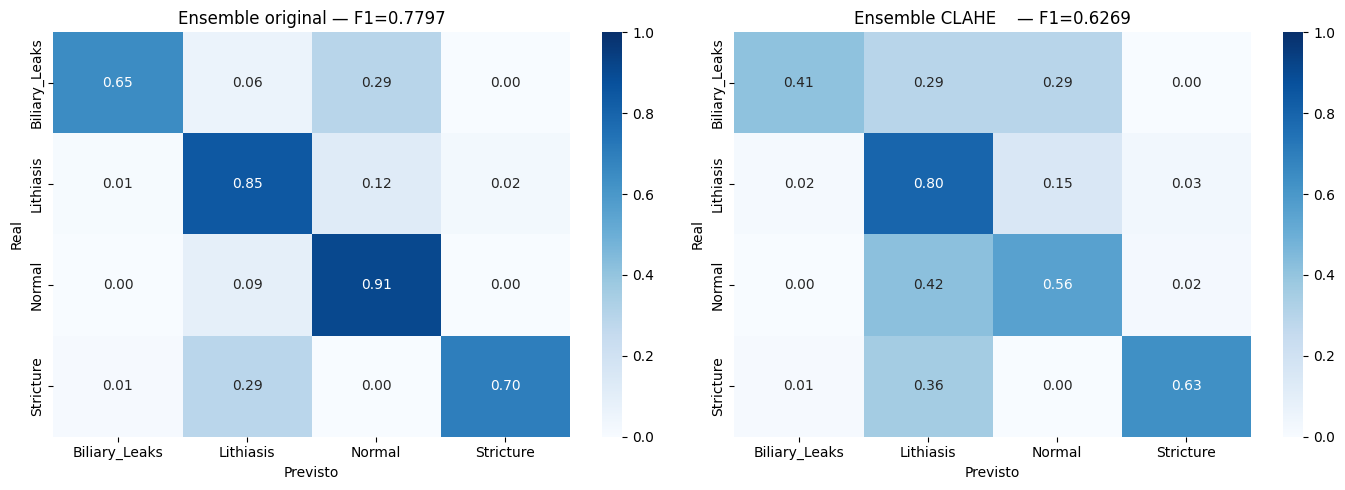

Figura guardada: ./preds/clahe_vs_original_ensemble.png


In [14]:
### Tabela comparativa CLAHE vs sem CLAHE + ensemble CLAHE
from sklearn.metrics import f1_score

# Carregar F1 XGB do run sem CLAHE a partir dos .npz guardados
no_clahe_xgb_f1 = {}
for tag in CLAHE_MODELS:
    npz_path = f'./preds/{tag}_predictions.npz'
    if os.path.exists(npz_path):
        d = np.load(npz_path, allow_pickle=True)
        no_clahe_xgb_f1[tag] = float(d['xgb_f1'])

print(f"\n{'Modelo':<15} {'XGB sem CLAHE':<16} {'XGB com CLAHE':<16} {'Delta':>8}")
print("-" * 58)
for tag in CLAHE_MODELS:
    if tag not in clahe_results:
        print(f"{tag:<15} (saltado)")
        continue
    f1_c  = clahe_results[tag]['f1']
    f1_b  = no_clahe_xgb_f1.get(tag, float('nan'))
    delta = f1_c - f1_b
    arrow = "+" if delta >= 0 else ""
    print(f"{tag:<15} {f1_b:<16.4f} {f1_c:<16.4f} {arrow}{delta:.4f}")

# Ensemble CLAHE (media simples)
done = [tag for tag in CLAHE_MODELS if tag in clahe_results]
if len(done) >= 2:
    stack = np.stack([clahe_results[t]['proba'] for t in done], axis=0)
    ens_cl = np.mean(stack, axis=0)
    act_cl = clahe_results[done[0]]['actuals']
    ens_cl_preds = ens_cl.argmax(1)
    ens_cl_f1    = f1_score(act_cl, ens_cl_preds, average='macro')

    ens_orig_f1 = f1_score(actuals_ref, ens_proba.argmax(1), average='macro')
    print(f"\n{'Ensemble CLAHE':<15} —               {ens_cl_f1:.4f}  (Ensemble orig: {ens_orig_f1:.4f}  Delta={ens_cl_f1-ens_orig_f1:+.4f})")
    print()
    print("=== Report Ensemble CLAHE ===")
    print(classification_report(act_cl, ens_cl_preds, target_names=class_names, digits=4, zero_division=0))

    # Figura comparativa
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import confusion_matrix
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, preds, act, title in zip(
        axes,
        [ens_proba.argmax(1),     ens_cl_preds],
        [actuals_ref,              act_cl],
        [f'Ensemble original — F1={ens_orig_f1:.4f}',
         f'Ensemble CLAHE    — F1={ens_cl_f1:.4f}']):
        cm = confusion_matrix(act, preds, normalize='true')
        sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
                    xticklabels=class_names, yticklabels=class_names, ax=ax)
        ax.set_title(title); ax.set_xlabel('Previsto'); ax.set_ylabel('Real')
    plt.tight_layout()
    plt.savefig('./preds/clahe_vs_original_ensemble.png', dpi=200, bbox_inches='tight')
    plt.show()
    print("Figura guardada: ./preds/clahe_vs_original_ensemble.png")

## 8. Grad-CAM (interpretabilidade — OBRIGATÓRIO no enunciado)

Corre esta célula DEPOIS de teres o último modelo carregado. Para o DeiT3 usa-se uma variante com reshape_transform; para os outros usa-se o último bloco convolucional.

Instala `grad-cam` se ainda não tens: `pip install grad-cam`.

C:\Users\bruno\AppData\Local\Temp\ipykernel_32176\2916826819.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gc_model.load_state_dict(torch.load(MODEL_PTH, map_location

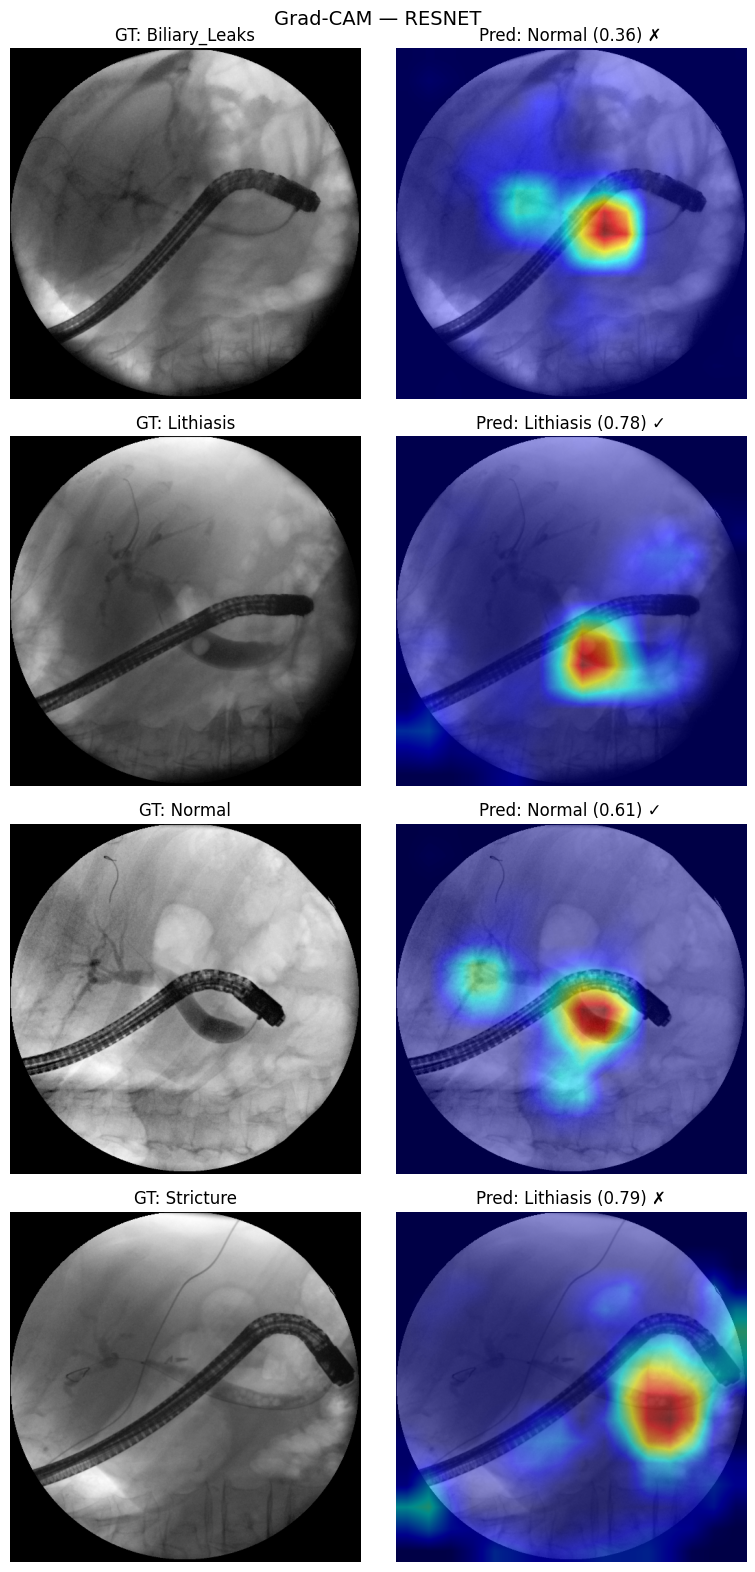

✅ Grad-CAM guardado em ./preds/resnet_gradcam.png


In [15]:
# Para o GradCAM, precisamos do modelo COM cabeça
if MODEL_TYPE == 'deit3':
    import timm
    gc_model = timm.create_model('deit3_small_patch16_384', pretrained=False, in_chans=3)
    gc_model.head = nn.Linear(gc_model.head.in_features, NUM_CLASS)
    target_layers = [gc_model.blocks[-1].norm1]
    def reshape_transform(tensor, h=24, w=24):
        result = tensor[:, 1:, :].reshape(tensor.size(0), h, w, tensor.size(2))
        return result.permute(0, 3, 1, 2)
elif MODEL_TYPE == 'densenet':
    from monai.networks.nets import DenseNet121
    gc_model = DenseNet121(spatial_dims=2, in_channels=3, out_channels=NUM_CLASS, pretrained=False)
    target_layers = [gc_model.features.denseblock4]
    reshape_transform = None
elif MODEL_TYPE == 'resnet':
    from torchvision.models import resnet50
    gc_model = resnet50(weights=None)
    gc_model.fc = nn.Linear(gc_model.fc.in_features, NUM_CLASS)
    target_layers = [gc_model.layer4[-1]]
    reshape_transform = None
elif MODEL_TYPE == 'efficientnet':
    from torchvision.models import efficientnet_b7
    gc_model = efficientnet_b7(weights=None)
    gc_model.classifier[1] = nn.Linear(gc_model.classifier[1].in_features, NUM_CLASS)
    target_layers = [gc_model.features[-1]]
    reshape_transform = None
elif MODEL_TYPE == 'mobilenet':
    from torchvision.models import mobilenet_v2
    gc_model = mobilenet_v2(weights=None)
    gc_model.classifier[1] = nn.Linear(gc_model.classifier[1].in_features, NUM_CLASS)
    target_layers = [gc_model.features[-1]]
    reshape_transform = None

gc_model.load_state_dict(torch.load(MODEL_PTH, map_location=device))
gc_model = gc_model.to(device).eval()

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

if reshape_transform is not None:
    cam = GradCAM(model=gc_model, target_layers=target_layers, reshape_transform=reshape_transform)
else:
    cam = GradCAM(model=gc_model, target_layers=target_layers)

# Selecionar 1 imagem por classe do teste
idx_by_class = {c: None for c in range(NUM_CLASS)}
for i, lbl in enumerate(data['test']['labels']):
    if idx_by_class[lbl] is None:
        idx_by_class[lbl] = i

fig, axes = plt.subplots(NUM_CLASS, 2, figsize=(8, 4*NUM_CLASS))
test_ds = ERCPDataset(data['test']['images'], data['test']['labels'], inference_transforms)

for c_idx in range(NUM_CLASS):
    t_idx = idx_by_class[c_idx]
    img_tensor, true_lbl = test_ds[t_idx]
    input_tensor = img_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = gc_model(input_tensor)
        pred = int(logits.argmax(1).item())
        prob = float(F.softmax(logits, dim=1).max().item())

    grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(pred)])[0]
    rgb_img = img_tensor.cpu().numpy()
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min() + 1e-6)
    rgb_img = rgb_img.transpose(1, 2, 0)
    rgb_img = np.clip(rgb_img, 0, 1)
    cam_img = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    axes[c_idx, 0].imshow(rgb_img); axes[c_idx, 0].axis('off')
    axes[c_idx, 0].set_title(f"GT: {class_names[true_lbl]}")
    axes[c_idx, 1].imshow(cam_img); axes[c_idx, 1].axis('off')
    ok = "✓" if pred == true_lbl else "✗"
    axes[c_idx, 1].set_title(f"Pred: {class_names[pred]} ({prob:.2f}) {ok}")

plt.suptitle(f"Grad-CAM — {MODEL_TYPE.upper()}", fontsize=14)
plt.tight_layout()
plt.savefig(f'./preds/{RUN_TAG}_gradcam.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"✅ Grad-CAM guardado em ./preds/{RUN_TAG}_gradcam.png")